In [249]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential
from datetime import datetime

Fetching the data

In [250]:
end = datetime.now().date()
start = datetime(end.year - 8, end.month, end.day)
stock = 'AAPL'

df = yf.download(stock, start, end)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-06-25,42.922096,43.570039,42.582809,43.211902,126652400
2018-06-26,43.454597,43.949392,43.009284,43.115314,98276800
2018-06-27,43.390984,44.126103,43.360352,43.643090,101141200
2018-06-28,43.706707,43.873996,43.306161,43.376846,69460800
2018-06-29,43.614822,44.104903,43.096469,43.892847,90950800


In [251]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2018-06-25,42.922096,43.570039,42.582809,43.211902,126652400
1,2018-06-26,43.454597,43.949392,43.009284,43.115314,98276800
2,2018-06-27,43.390984,44.126103,43.360352,43.643090,101141200
3,2018-06-28,43.706707,43.873996,43.306161,43.376846,69460800
4,2018-06-29,43.614822,44.104903,43.096469,43.892847,90950800


In [252]:
df = df.drop(['Date'], axis=1)
df.head()

/tmp/ipykernel_15444/2218488136.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date'], axis=1)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,42.922096,43.570039,42.582809,43.211902,126652400
1,43.454597,43.949392,43.009284,43.115314,98276800
2,43.390984,44.126103,43.360352,43.643090,101141200
3,43.706707,43.873996,43.306161,43.376846,69460800
4,43.614822,44.104903,43.096469,43.892847,90950800


Observing the close price trend

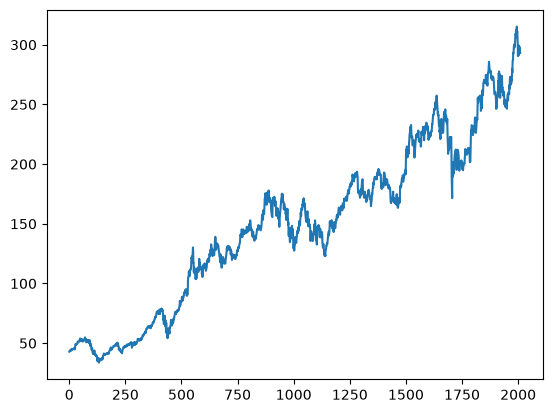

In [253]:
plt.plot(df.Close)

Calculating and observing moving average 100

In [254]:
ma100 = df.Close.rolling(window=100).mean()
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2005,274.117824
2006,274.548561
2007,274.940751
2008,275.324106


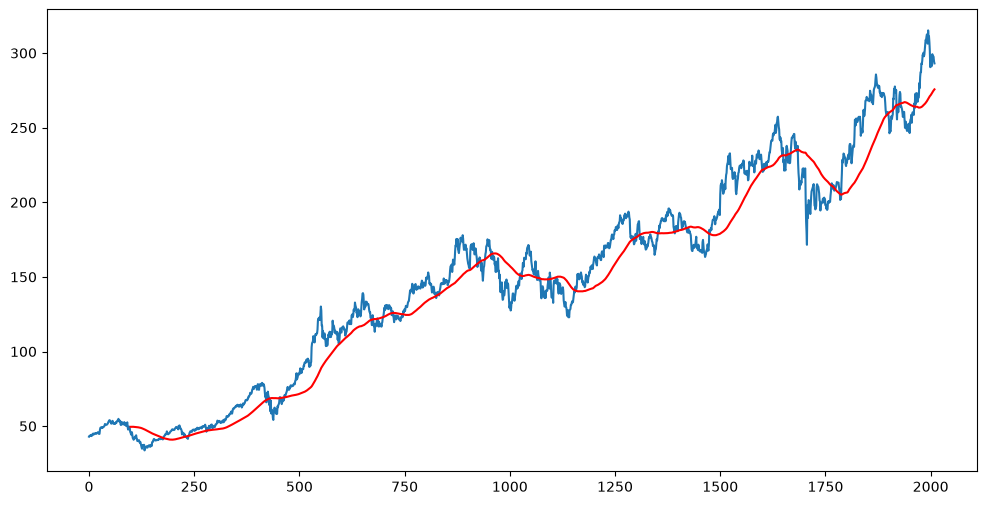

In [255]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close)
plt.plot(ma100, 'r')

Calculating and observing moving average 200

In [256]:
ma200 = df.Close.rolling(window=200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2005,267.448310
2006,267.793001
2007,268.089064
2008,268.365047


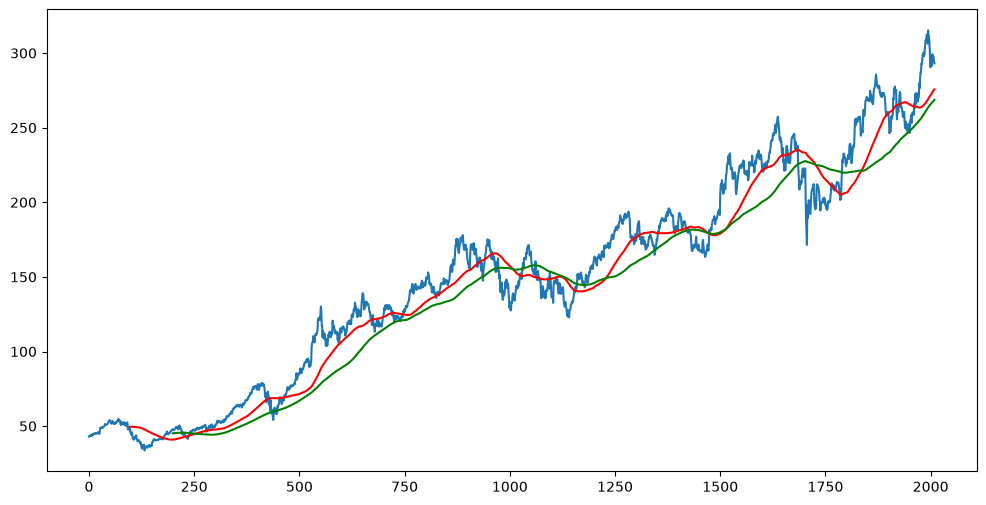

In [257]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

In [258]:
df.shape

(2010, 5)

Splitting data into training and testing data

In [259]:
data_training = pd.DataFrame(df['Close'][0: int(len(df) * 0.80)])
data_testing = pd.DataFrame(df['Close'][int(len(df) * 0.80): int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(1608, 1)
(402, 1)


In [260]:
data_training.head()

Ticker,AAPL
0,42.922096
1,43.454597
2,43.390984
3,43.706707
4,43.614822


In [261]:
data_testing.head()

Ticker,AAPL
1608,223.690826
1609,226.771133
1610,223.571579
1611,226.572433
1612,226.830765


Scailing the data

In [262]:
scaler = MinMaxScaler(feature_range=(0, 1))

data_training_array_scale = scaler.fit_transform(data_training)

In [263]:
x_train = []
y_train = []

for i in range(100, data_training_array_scale.shape[0]):
    x_train.append(data_training_array_scale[i-100: i])
    y_train.append(data_training_array_scale[i: 0])

x_train, y_train = np.array(x_train), np.array(y_train)

Setting up the model

In [264]:
model = Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True,))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

/home/subhadip/Desktop/Stock-Price-Predtiction-Model/venv/lib/python3.14/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [265]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)